In [1]:
import pickle

from neurotools import modules, util, models
import torch
import torchvision
from torchvision.datasets.mnist import FashionMNIST, MNIST
import networkx as nx
from matplotlib import pyplot as plt

In [2]:
batch_size_train = 100
batch_size_test = 100
train_loader = torch.utils.data.DataLoader(
    FashionMNIST('./tmp/files/', train=True, download=True,
                               transform=torchvision.transforms.Compose([
                                   torchvision.transforms.ToTensor(),
                                   torchvision.transforms.Normalize(
                                       (0.5), (0.5,))
                               ])),
    batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    FashionMNIST('./tmp/files/', train=False, download=True,
                               transform=torchvision.transforms.Compose([
                                   torchvision.transforms.ToTensor(),
                                   torchvision.transforms.Normalize(
                                       (0.5,), (0.5,))
                               ])),
    batch_size=batch_size_test, shuffle=True)

In [10]:
class MapDecode(torch.nn.Module):
    def __init__(self, spatial, num_targets, dev='cuda'):
        super().__init__()
        self.spatial = spatial
        kernel, pad = util.conv_identity_params(spatial, desired_kernel=3)
        self.default_mask = torch.nn.Parameter(torch.ones((1, 1, spatial, spatial), device=dev))
        self.conv1 = torch.nn.Conv2d(kernel_size=kernel, padding=pad, in_channels=1, out_channels=16, device=dev)
        self.pool_2f = torch.nn.MaxPool2d(kernel_size=2) # 14
        kernel, pad = util.conv_identity_params(14, desired_kernel=3)
        self.conv2 = torch.nn.Conv2d(kernel_size=kernel, padding=pad, in_channels=16, out_channels=24, device=dev)
        kernel, pad = util.conv_identity_params(7, desired_kernel=3)
        self.conv3 = torch.nn.Conv2d(kernel_size=kernel, padding=pad, in_channels=24, out_channels=16, device=dev)
        self.pool_7f = torch.nn.MaxPool2d(kernel_size=7)
        self.conv_out = torch.nn.Conv2d(kernel_size=1, padding=0, in_channels=16, out_channels=10, device=dev)

    def forward(self, x):
        x = x * self.default_mask
        h = self.conv1(x)
        h = self.pool_2f(h)
        h = self.conv2(h)
        h = self.pool_2f(h)
        h = self.conv3(h)
        h = self.pool_7f(h)
        yhat = self.conv_out(h)
        yhat = torch.log_softmax(yhat, dim=1).squeeze()
        return yhat

dev = 'cuda'
lfxn = torch.nn.NLLLoss()
model = MapDecode(28, dev=dev, num_targets=10)
optim = torch.optim.Adam(lr=.01, params=model.parameters())
for epoch in range(10):
    epoch_loss = 0
    count = 0
    for i, (stim, target) in enumerate(train_loader):
        optim.zero_grad()
        y_hat = model(stim.to(dev))
        targets = target.long().to(dev)
        tloss = lfxn(y_hat, targets)
        l1loss = torch.abs(model.default_mask).mean()
        loss = tloss + 10 * l1loss
        epoch_loss += loss.detach().cpu().item()
        loss.backward()
        optim.step()
        count += 1
    print("Loss epoch", epoch, "is", epoch_loss / count)

Loss epoch 0 is 1.747322082320849
Loss epoch 1 is 0.7448257593313853
Loss epoch 2 is 0.7099570991595586
Loss epoch 3 is 0.6958060487608115
Loss epoch 4 is 0.6910827847818534
Loss epoch 5 is 0.6810011864205201
Loss epoch 6 is 0.6778856494526069
Loss epoch 7 is 0.674198314845562
Loss epoch 8 is 0.6755129871269067
Loss epoch 9 is 0.6824620419243972


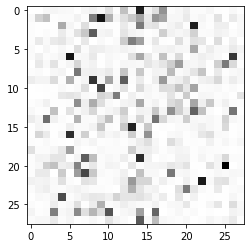

In [11]:
mask_im = torch.abs(model.default_mask.detach().cpu()).numpy()
plt.imshow(mask_im.squeeze(), cmap="Greys")